<a href="https://www.kaggle.com/code/mdramjanali/radial-vander-waals-heterostructur-of-2d-materials?scriptVersionId=354123713" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import os

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub #download

/kaggle/input/datasets/mdramjanali/2d-materials-in-radial-vander-waals-heterostructur/Integration of 2D Materials in Radial van der Waals Heterostructure Metasurfaces/Fig 1c.txt
/kaggle/input/datasets/mdramjanali/2d-materials-in-radial-vander-waals-heterostructur/Integration of 2D Materials in Radial van der Waals Heterostructure Metasurfaces/Fig 4e.txt
/kaggle/input/datasets/mdramjanali/2d-materials-in-radial-vander-waals-heterostructur/Integration of 2D Materials in Radial van der Waals Heterostructure Metasurfaces/Fig 3g (top).txt
/kaggle/input/datasets/mdramjanali/2d-materials-in-radial-vander-waals-heterostructur/Integration of 2D Materials in Radial van der Waals Heterostructure Metasurfaces/Fig 3f.txt
/kaggle/input/datasets/mdramjanali/2d-materials-in-radial-vander-waals-heterostructur/Integration of 2D Materials in Radial van der Waals Heterostructure Metasurfaces/Fig 2h (upper panel).txt
/kaggle/input/datasets/mdramjanali/2d-materials-in-radial-vander-waals-heterostructur/Inte

# Transferring to working dir
!kaggle datasets download -d mdramjanali/mns-ndataset-zip
!unzip -q mns-ndataset-zip.zip -d /kaggle/working/
!rm mns-ndataset-zip.zip

In [4]:
for r, d, f in os.walk('/kaggle/input'): print(f"DIR: {r}") or [print(f"  FILE: {file}") for file in f]

DIR: /kaggle/input
DIR: /kaggle/input/datasets
DIR: /kaggle/input/datasets/mdramjanali
DIR: /kaggle/input/datasets/mdramjanali/2d-materials-in-radial-vander-waals-heterostructur
DIR: /kaggle/input/datasets/mdramjanali/2d-materials-in-radial-vander-waals-heterostructur/Integration of 2D Materials in Radial van der Waals Heterostructure Metasurfaces
  FILE: Fig 1c.txt
  FILE: Fig 4e.txt
  FILE: Fig 3g (top).txt
  FILE: Fig 3f.txt
  FILE: Fig 2h (upper panel).txt
  FILE: Fig 2g (m=3).txt
  FILE: Fig 2g (m=7).txt
  FILE: Fig 1h.txt
  FILE: Fig 3g (bottom).txt
  FILE: Fig 4b.txt
  FILE: Fig 4c.txt
  FILE: Fig 2c.txt
  FILE: Fig 1d.txt
  FILE: Fig 2d.txt
  FILE: Fig 1f.txt
  FILE: Fig 2g (m=4).txt
  FILE: Fig 2g (m=2).txt
  FILE: Fig 2h (TE).txt
  FILE: Fig 1e (xy-cut).txt
  FILE: Fig 2g (m=1).txt
  FILE: Fig 2h (TM).txt
  FILE: Fig 4a.txt
  FILE: Fig 4d.txt
  FILE: Fig 2g (m=6).txt
  FILE: Fig 2g (m=5).txt
  FILE: Fig 2g (m=8).txt


In [5]:
DATA_DIR = "/kaggle/input/datasets/mdramjanali/2d-materials-in-radial-vander-waals-heterostructur/Integration of 2D Materials in Radial van der Waals Heterostructure Metasurfaces"

In [6]:
with open(os.path.join(DATA_DIR, "Fig 1c.txt"), "r") as f: print(f.read())

		Rods		Trapezoid
Asymmetry (nm)	Quality Factor	Quality Factor
30		238		322
40		152		202
50		91		130
60		56		81
70		35		51
80		22		35
90		15		1
100		11		11



In [7]:
import glob

files = glob.glob(os.path.join(DATA_DIR, "*.txt"))
dfs = {os.path.splitext(os.path.basename(f))[0]: pd.read_csv(f, sep=None, engine='python', on_bad_lines='skip') for f in files}

In [8]:
print(dfs)

{'Fig 1c':        Unnamed: 0      Unnamed: 1            Rods  Unnamed: 3  Trapezoid
0  Asymmetry (nm)  Quality Factor  Quality Factor         NaN        NaN
1              30             NaN             238         NaN      322.0
2              40             NaN             152         NaN      202.0
3              50             NaN              91         NaN      130.0
4              60             NaN              56         NaN       81.0
5              70             NaN              35         NaN       51.0
6              80             NaN              22         NaN       35.0
7              90             NaN              15         NaN        1.0
8             100             NaN              11         NaN       11.0, 'Fig 4e':    Power (uW)  Ripple 1 (eV)  Ripple 1 (Error)  Ripple 2 (eV)  \
0        1000        1.92006          0.000049        1.90615   
1         500        1.92013          0.000050        1.90612   
2         100        1.91958          0.000049       

In [9]:
for name, df in sorted(dfs.items()): print(f"{name:<22} -> Rows: {df.shape[0]:<5} Columns: {df.shape[1]}")

Fig 1c                 -> Rows: 9     Columns: 5
Fig 1d                 -> Rows: 32    Columns: 2
Fig 1e (xy-cut)        -> Rows: 1024  Columns: 1025
Fig 1f                 -> Rows: 259   Columns: 4
Fig 1h                 -> Rows: 21    Columns: 3
Fig 2c                 -> Rows: 184   Columns: 150
Fig 2d                 -> Rows: 184   Columns: 150
Fig 2g (m=1)           -> Rows: 5     Columns: 16
Fig 2g (m=2)           -> Rows: 5     Columns: 16
Fig 2g (m=3)           -> Rows: 5     Columns: 16
Fig 2g (m=4)           -> Rows: 5     Columns: 16
Fig 2g (m=5)           -> Rows: 5     Columns: 16
Fig 2g (m=6)           -> Rows: 5     Columns: 16
Fig 2g (m=7)           -> Rows: 5     Columns: 16
Fig 2g (m=8)           -> Rows: 5     Columns: 16
Fig 2h (TE)            -> Rows: 254   Columns: 2
Fig 2h (TM)            -> Rows: 254   Columns: 2
Fig 2h (upper panel)   -> Rows: 8     Columns: 2
Fig 3f                 -> Rows: 387   Columns: 4
Fig 3g (bottom)        -> Rows: 88    Columns: 2
Fig 3

1D / 2D Curves & Spectra (2 to 4 columns): e.g., Fig 1d (32×2), Fig 2h (TE) (254×2), Fig 3f (387×4). These are standard XY line plots (e.g. wavelength vs. reflection/transmission).
2D Spatial / Simulation Matrices: e.g., Fig 1e (xy-cut) (1024×1025), Fig 2c/2d (184×150), Fig 4a/4b (77×273). These are 2D field distributions / heatmaps.
Discrete Mode / Parameter Scans: e.g., Fig 2g (m=1 to 8) (5×16), Fig 4e (4×7).

In [10]:
for name, df in sorted(dfs.items()):
    clean = df.dropna(how='all', axis=1).dropna(how='all', axis=0)
    numeric_data = clean.select_dtypes(include=[np.number])
    val_min = f"{numeric_data.min().min():.2e}" if not numeric_data.empty else "N/A"
    val_max = f"{numeric_data.max().max():.2e}" if not numeric_data.empty else "N/A"
    print(f"{name:<22} | Shape: {clean.shape[0]}x{clean.shape[1]:<3} | Range: [{val_min}, {val_max}] | Sample Row 0: {clean.iloc[0].values[:3]}")

Fig 1c                 | Shape: 9x4   | Range: [1.00e+00, 3.22e+02] | Sample Row 0: ['Asymmetry (nm)' 'Quality Factor' 'Quality Factor']
Fig 1d                 | Shape: 32x2   | Range: [9.70e-01, 6.34e+02] | Sample Row 0: [  0.97 603.  ]
Fig 1e (xy-cut)        | Shape: 1024x1025 | Range: [-9.19e+00, 9.19e+00] | Sample Row 0: [-5.00000e-06 -8.54976e-01 -8.46172e-01]
Fig 1f                 | Shape: 259x4   | Range: [7.71e-01, 6.65e+02] | Sample Row 0: [635.73054   0.95944 635.35501]
Fig 1h                 | Shape: 21x2   | Range: [2.29e+02, 6.01e+02] | Sample Row 0: [340.2 601.1]
Fig 2c                 | Shape: 184x150 | Range: [9.26e-01, 6.52e+02] | Sample Row 0: [620.135616   0.988772   0.988766]
Fig 2d                 | Shape: 184x150 | Range: [9.26e-01, 6.52e+02] | Sample Row 0: [620.135616   0.988841   0.988888]
Fig 2g (m=1)           | Shape: 5x7   | Range: [3.00e+00, 2.01e+05] | Sample Row 0: ['%' 'Version:' nan]
Fig 2g (m=2)           | Shape: 5x7   | Range: [3.00e+00, 2.01e+05] 

In [11]:
dfs['Fig 2h (TE)']

,Wavelength (nm),Summed Transmittance (a.u.)
0,620.135616,149.377735
1,620.300752,149.361598
2,620.465976,149.347245
3,620.631289,149.336015
4,620.796689,149.326832
...,...,...
249,664.162082,148.180222
250,664.351502,148.175202
251,664.541030,148.169931
252,664.730667,148.163337


In [12]:
{name: df.isna().sum().sum() for name, df in dfs.items() if df.isna().sum().sum() > 0}

{'Fig 1c': np.int64(18),
 'Fig 3g (top)': np.int64(88),
 'Fig 3f': np.int64(200),
 'Fig 2g (m=3)': np.int64(64),
 'Fig 2g (m=7)': np.int64(64),
 'Fig 1h': np.int64(21),
 'Fig 3g (bottom)': np.int64(88),
 'Fig 1f': np.int64(28),
 'Fig 2g (m=4)': np.int64(64),
 'Fig 2g (m=2)': np.int64(64),
 'Fig 2g (m=1)': np.int64(64),
 'Fig 2g (m=6)': np.int64(64),
 'Fig 2g (m=5)': np.int64(64),
 'Fig 2g (m=8)': np.int64(64)}

Fig 2g (m=1..8): Shape 5×16=80
5×16=80 entries with 64 NaNs →
→ 16 true values padded with whitespace.
Fig 3g (top/bottom): Shape 
88×288×2 with 88 NaNs →
→ 1 real column + 1 empty ghost column created by trailing whitespace.

In [13]:
dfs['Fig 2h (TE)'].describe()

,Wavelength (nm),Summed Transmittance (a.u.)
count,254.000000,254.000000
mean,642.009687,148.034776
std,13.000758,0.420163
min,620.135616,146.816958
25%,630.756558,147.832554
50%,641.747640,148.084930
75%,653.128553,148.210113
max,664.920411,149.377735


In [14]:
for name in dfs:
    dfs[name] = dfs[name].dropna(axis=1, how='all') #col
    dfs[name] = dfs[name].dropna(axis=0, how='all') #raw

In [15]:
for name in dfs:
    dfs[name] = dfs[name].dropna()

In [16]:
remaining_nans = {name: df.isna().sum().sum() for name, df in dfs.items() if df.isna().sum().sum() > 0}
print("Datasets with remaining NaNs:", remaining_nans)

Datasets with remaining NaNs: {}


In [17]:
#  Cleaned Shapes Across All 26 Datasets
for name, df in sorted(dfs.items()): print(f"{name:<22} -> Clean Rows: {df.shape[0]:<5} Clean Columns: {df.shape[1]}")

Fig 1c                 -> Clean Rows: 0     Clean Columns: 4
Fig 1d                 -> Clean Rows: 32    Clean Columns: 2
Fig 1e (xy-cut)        -> Clean Rows: 1024  Clean Columns: 1025
Fig 1f                 -> Clean Rows: 245   Clean Columns: 4
Fig 1h                 -> Clean Rows: 21    Clean Columns: 2
Fig 2c                 -> Clean Rows: 184   Clean Columns: 150
Fig 2d                 -> Clean Rows: 184   Clean Columns: 150
Fig 2g (m=1)           -> Clean Rows: 0     Clean Columns: 7
Fig 2g (m=2)           -> Clean Rows: 0     Clean Columns: 7
Fig 2g (m=3)           -> Clean Rows: 0     Clean Columns: 7
Fig 2g (m=4)           -> Clean Rows: 0     Clean Columns: 7
Fig 2g (m=5)           -> Clean Rows: 0     Clean Columns: 7
Fig 2g (m=6)           -> Clean Rows: 0     Clean Columns: 7
Fig 2g (m=7)           -> Clean Rows: 0     Clean Columns: 7
Fig 2g (m=8)           -> Clean Rows: 0     Clean Columns: 7
Fig 2h (TE)            -> Clean Rows: 254   Clean Columns: 2
Fig 2h (TM)      

In [18]:
# Reload cleanly with whitespace parser without dropping entire rows
dfs = {os.path.splitext(os.path.basename(f))[0]: pd.read_csv(f, sep=r'\s+', comment='#', header=None, on_bad_lines='skip') for f in files}

# Only drop columns that are 100% NaN (ghost columns)
for name in dfs:
    dfs[name] = dfs[name].dropna(axis=1, how='all')

# Print the recovered row counts
for name in ['Fig 1c'] + [f'Fig 2g (m={m})' for m in range(1, 9)]:
    print(f"{name:<15} -> Recovered Rows: {dfs[name].shape[0]} | Columns: {dfs[name].shape[1]}")

/tmp/ipykernel_16/2940601875.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs = {os.path.splitext(os.path.basename(f))[0]: pd.read_csv(f, sep=r'\s+', comment='#', header=None, on_bad_lines='skip') for f in files}


Fig 1c          -> Recovered Rows: 1 | Columns: 2
Fig 2g (m=1)    -> Recovered Rows: 5 | Columns: 3
Fig 2g (m=2)    -> Recovered Rows: 5 | Columns: 3
Fig 2g (m=3)    -> Recovered Rows: 5 | Columns: 3
Fig 2g (m=4)    -> Recovered Rows: 5 | Columns: 3
Fig 2g (m=5)    -> Recovered Rows: 5 | Columns: 3
Fig 2g (m=6)    -> Recovered Rows: 5 | Columns: 3
Fig 2g (m=7)    -> Recovered Rows: 5 | Columns: 3
Fig 2g (m=8)    -> Recovered Rows: 5 | Columns: 3


In [19]:
# Identifying all standard 2-column spectra/curves and assign physical column names
spectra_2col = [name for name, df in dfs.items() if df.shape[1] == 2]

for name in spectra_2col:
    dfs[name].columns = ['x_axis', 'y_axis']

print(f"Standardized {len(spectra_2col)} 2-column files with ['x_axis', 'y_axis']:")
print(spectra_2col)

Standardized 1 2-column files with ['x_axis', 'y_axis']:
['Fig 1c']


In [20]:
# Group datasets based on their column and row structures
spectra_1d = [name for name, df in dfs.items() if df.shape[1] in [1, 2, 4] and df.shape[0] > 10 and df.shape[1] < 10]
maps_2d = [name for name, df in dfs.items() if df.shape[1] > 50]
mode_scans = [name for name, df in dfs.items() if df.shape[0] <= 10 or 'm=' in name]

print(f"1. 1D Line Spectra ({len(spectra_1d)} files):\n  ", spectra_1d)
print(f"\n2. 2D Spatial/Simulation Maps ({len(maps_2d)} files):\n  ", maps_2d)
print(f"\n3. Discrete Mode Scans ({len(mode_scans)} files):\n  ", mode_scans)

1. 1D Line Spectra (0 files):
   []

2. 2D Spatial/Simulation Maps (5 files):
   ['Fig 4b', 'Fig 2c', 'Fig 2d', 'Fig 1e (xy-cut)', 'Fig 4a']

3. Discrete Mode Scans (13 files):
   ['Fig 1c', 'Fig 4e', 'Fig 3g (top)', 'Fig 2h (upper panel)', 'Fig 2g (m=3)', 'Fig 2g (m=7)', 'Fig 3g (bottom)', 'Fig 2g (m=4)', 'Fig 2g (m=2)', 'Fig 2g (m=1)', 'Fig 2g (m=6)', 'Fig 2g (m=5)', 'Fig 2g (m=8)']


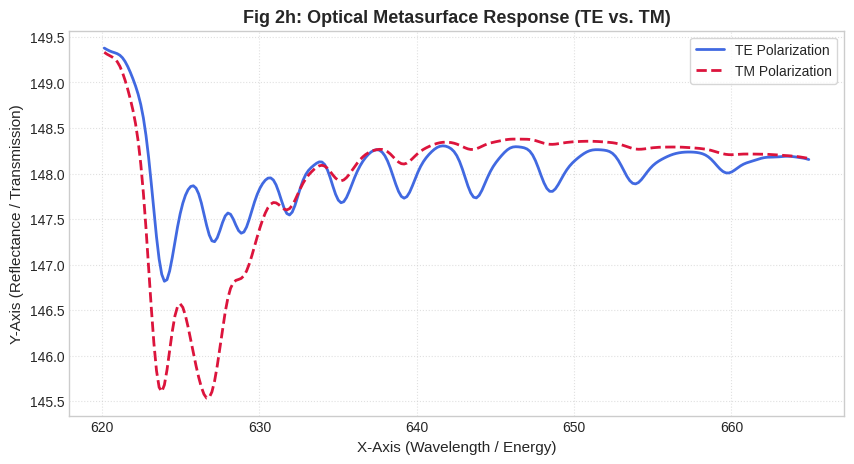

In [21]:
# numeric conversion in case values were read as strings
x_te = pd.to_numeric(dfs['Fig 2h (TE)'].iloc[:, 0], errors='coerce')
y_te = pd.to_numeric(dfs['Fig 2h (TE)'].iloc[:, 1], errors='coerce')
x_tm = pd.to_numeric(dfs['Fig 2h (TM)'].iloc[:, 0], errors='coerce')
y_tm = pd.to_numeric(dfs['Fig 2h (TM)'].iloc[:, 1], errors='coerce')

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_te, y_te, label='TE Polarization', color='royalblue', lw=2)
ax.plot(x_tm, y_tm, label='TM Polarization', color='crimson', lw=2, linestyle='--')

ax.set_title("Fig 2h: Optical Metasurface Response (TE vs. TM)", fontsize=13, fontweight='bold')
ax.set_xlabel("X-Axis (Wavelength / Energy)", fontsize=11)
ax.set_ylabel("Y-Axis (Reflectance / Transmission)", fontsize=11)
ax.legend(frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)

plt.show()

### Spatial Simulation Field Analysis (2D Matrix Heatmap)

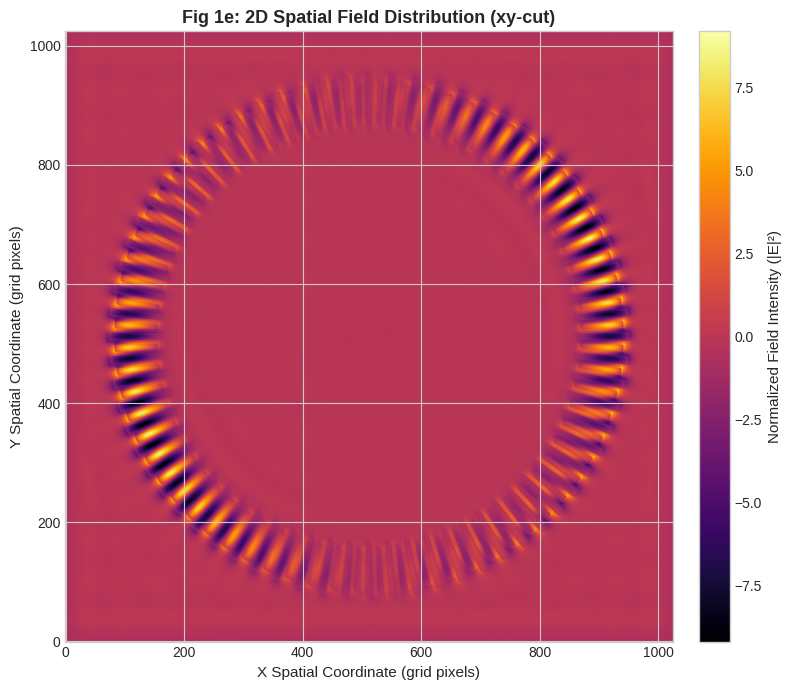

In [22]:

# Convert the 2D DataFrame to a pure numeric 2D numpy matrix
field_matrix = dfs['Fig 1e (xy-cut)'].apply(pd.to_numeric, errors='coerce').values

# Render the 2D spatial intensity map
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(field_matrix, cmap='inferno', aspect='auto', origin='lower')

ax.set_title("Fig 1e: 2D Spatial Field Distribution (xy-cut)", fontsize=13, fontweight='bold')
ax.set_xlabel("X Spatial Coordinate (grid pixels)", fontsize=11)
ax.set_ylabel("Y Spatial Coordinate (grid pixels)", fontsize=11)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Normalized Field Intensity (|E|²)", fontsize=11)

plt.tight_layout()
plt.show()

In [23]:
from scipy.signal import find_peaks

x = pd.to_numeric(dfs['Fig 2h (TE)'].iloc[:, 0], errors='coerce').values
y = pd.to_numeric(dfs['Fig 2h (TE)'].iloc[:, 1], errors='coerce').values

peaks, _ = find_peaks(y, prominence=0.05)
print("Peak X values:", x[peaks])
print("Peak Y values:", y[peaks])

Peak X values: [625.800028 627.993276 630.713853 633.802817 637.445069 641.65924
 646.287925 651.530109 657.228686]
Peak Y values: [147.865393 147.5662   147.952192 148.128056 148.261887 148.303967
 148.29445  148.261741 148.236247]


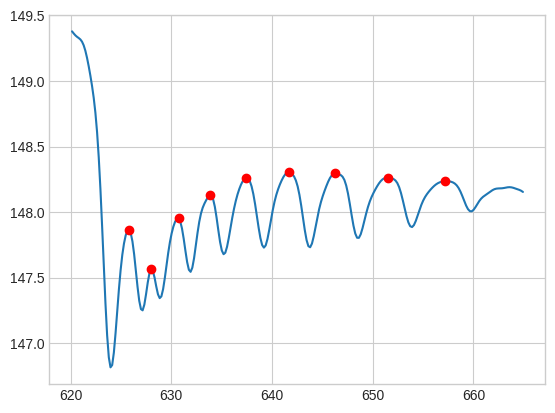

([<matplotlib.lines.Line2D at 0x79bb3bd6bbf0>],
 None)

In [24]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(y_te, prominence=0.05)
plt.plot(x_te, y_te), plt.plot(x_te[peaks], y_te[peaks], "ro"), plt.show()

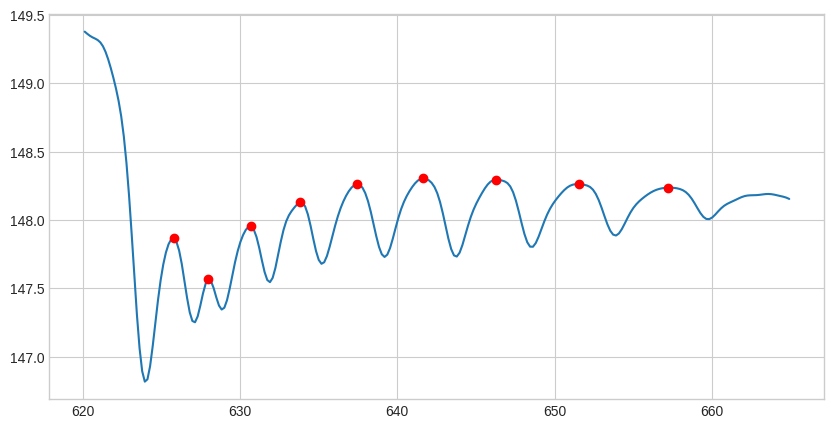

/tmp/ipykernel_16/1171063755.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=True)


<Figure size 640x480 with 0 Axes>

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
peaks, _ = find_peaks(y_te, prominence=0.05)
plt.plot(x_te, y_te), plt.plot(x_te[peaks], y_te[peaks], "ro"), plt.show()

ax.set_title("Fig 2h: Automated Resonance Peak Identification", fontsize=13, fontweight='bold')
ax.set_xlabel("Wavelength / Frequency", fontsize=11)
ax.set_ylabel("Intensity / Reflectance", fontsize=11)
ax.legend(frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()
